# Camp 3 — Systems & Flow
### Data GOLD Field Notes · Series Demo 04

Six terms, four sections: **Distributed Systems & Message Queue** together, **Caching** on its own, **Orchestration & Workflow Scheduler** together, and **Data Governance** closing it out.

Each section is self-contained. Run top to bottom, or jump to the term you're studying.


## Setup

In [2]:
import time
import random
import queue
import threading
import concurrent.futures
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from datetime import datetime

random.seed(42)


## Section A — Distributed Systems & Message Queue

Multiple machines acting as one, and the mechanism that lets them talk without waiting on each other.


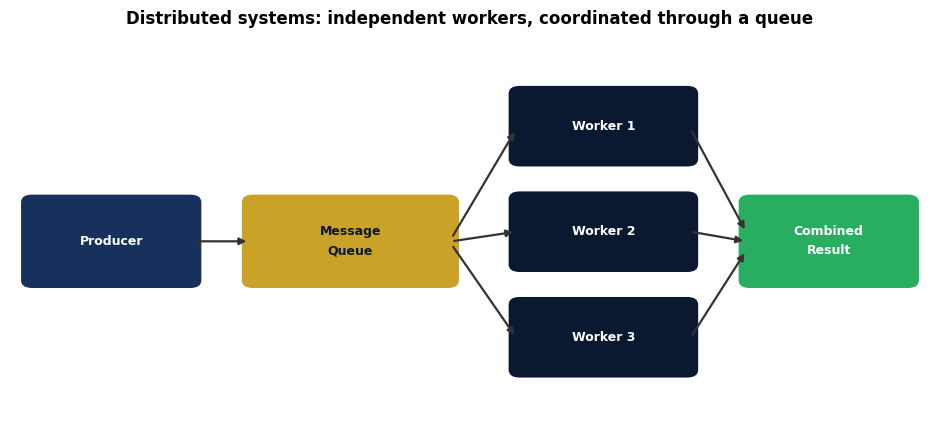

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis("off")

def box(x, y, w, h, text, facecolor, textcolor="white", fontsize=9):
    ax.add_patch(FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.08,rounding_size=0.12",
        facecolor=facecolor, edgecolor="none"
    ))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center",
            color=textcolor, fontsize=fontsize, fontweight="bold", linespacing=1.6)

def arrow(x1, y1, x2, y2, color="#333333"):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=1.6, shrinkA=2, shrinkB=2))

box(0.2, 2.3, 1.8, 1.3, "Producer", "#17305C")
box(2.6, 2.3, 2.2, 1.3, "Message\nQueue", "#C9A227", textcolor="#0A1830")

box(5.5, 4.2, 1.9, 1.1, "Worker 1", "#0A1830")
box(5.5, 2.55, 1.9, 1.1, "Worker 2", "#0A1830")
box(5.5, 0.9, 1.9, 1.1, "Worker 3", "#0A1830")

box(8.0, 2.3, 1.8, 1.3, "Combined\nResult", "#27AE60", textcolor="white")

arrow(2.0, 2.95, 2.6, 2.95)
arrow(4.8, 3.0, 5.5, 4.7)
arrow(4.8, 2.95, 5.5, 3.1)
arrow(4.8, 2.9, 5.5, 1.45)
arrow(7.4, 4.7, 8.0, 3.1)
arrow(7.4, 3.1, 8.0, 2.95)
arrow(7.4, 1.45, 8.0, 2.8)

ax.set_title("Distributed systems: independent workers, coordinated through a queue",
             fontsize=12, fontweight="bold", pad=16)
plt.tight_layout()
plt.show()


### 1. Distributed Systems — many workers, one result


In [6]:
def worker_process(chunk, worker_id):
    subtotal = round(sum(t["amount"] for t in chunk), 2)
    return {"worker": worker_id, "records": len(chunk), "subtotal": subtotal}

transactions = [{"txn_id": i, "amount": round(random.uniform(5, 500), 2)} for i in range(1, 1201)]

NUM_WORKERS = 4
chunk_size = len(transactions) // NUM_WORKERS
chunks = [transactions[i * chunk_size:(i + 1) * chunk_size] for i in range(NUM_WORKERS)]

with concurrent.futures.ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    futures = [executor.submit(worker_process, chunk, i) for i, chunk in enumerate(chunks)]
    results = [f.result() for f in futures]

print(f"{len(transactions):,} transactions split across {NUM_WORKERS} independent workers:\n")
for r in sorted(results, key=lambda r: r["worker"]):
    print(f"  worker {r['worker']}: {r['records']} records, subtotal ${r['subtotal']:,}")

grand_total = round(sum(r["subtotal"] for r in results), 2)
print(f"\nCombined result, {NUM_WORKERS} machines acting as one system: ${grand_total:,}")


1,200 transactions split across 4 independent workers:

  worker 0: 300 records, subtotal $74,735.22
  worker 1: 300 records, subtotal $77,311.41
  worker 2: 300 records, subtotal $78,278.09
  worker 3: 300 records, subtotal $75,548.51

Combined result, 4 machines acting as one system: $305,873.23


### 2. Message Queue — decoupled producer and consumer


In [8]:
work_queue = queue.Queue()
processed = []

def producer(n):
    for i in range(n):
        msg = {"event_id": i, "payload": f"order-{i}"}
        work_queue.put(msg)
        print(f"  producer enqueued {msg}")
    work_queue.put(None)  # sentinel signals "no more messages"

def consumer():
    while True:
        msg = work_queue.get()
        if msg is None:
            break
        time.sleep(0.01)  # simulate work the consumer does per message
        processed.append(msg)
        print(f"    consumer processed {msg}")

print("Producer runs first, fully, without waiting on the consumer at all:\n")
producer(5)

print("\nConsumer catches up on its own schedule, independently:\n")
consumer()

print(f"\n{len(processed)} messages processed, with zero direct coupling between producer and consumer.")


Producer runs first, fully, without waiting on the consumer at all:

  producer enqueued {'event_id': 0, 'payload': 'order-0'}
  producer enqueued {'event_id': 1, 'payload': 'order-1'}
  producer enqueued {'event_id': 2, 'payload': 'order-2'}
  producer enqueued {'event_id': 3, 'payload': 'order-3'}
  producer enqueued {'event_id': 4, 'payload': 'order-4'}

Consumer catches up on its own schedule, independently:

    consumer processed {'event_id': 0, 'payload': 'order-0'}
    consumer processed {'event_id': 1, 'payload': 'order-1'}
    consumer processed {'event_id': 2, 'payload': 'order-2'}
    consumer processed {'event_id': 3, 'payload': 'order-3'}
    consumer processed {'event_id': 4, 'payload': 'order-4'}

5 messages processed, with zero direct coupling between producer and consumer.


## Section B — Caching

Keeps frequently used data close by. Below: the same lookup called three times, hitting a slow "database" only once.


In [10]:
_db_calls = 0

def slow_lookup(customer_id):
    global _db_calls
    _db_calls += 1
    time.sleep(0.05)  # simulate a slow database round trip
    return {"customer_id": customer_id, "mrr": round(random.uniform(20, 300), 2)}

cache = {}

def cached_lookup(customer_id):
    if customer_id in cache:
        return cache[customer_id], True
    result = slow_lookup(customer_id)
    cache[customer_id] = result
    return result, False

for call_num in range(1, 4):
    start = time.perf_counter()
    result, hit = cached_lookup(42)
    elapsed_ms = (time.perf_counter() - start) * 1000
    label = "cache HIT" if hit else "cache MISS (hit the database)"
    print(f"Call {call_num}: {label} -> {elapsed_ms:6.2f} ms")

print(f"\nDatabase was actually queried {_db_calls} time(s) across 3 calls to the same customer.")


Call 1: cache MISS (hit the database) ->  50.62 ms
Call 2: cache HIT ->   0.00 ms
Call 3: cache HIT ->   0.00 ms

Database was actually queried 1 time(s) across 3 calls to the same customer.


## Section C — Orchestration & Workflow Scheduler

Orchestration decides *how* a multi-step job runs, resolving dependencies automatically. A scheduler decides *when* that job fires, whether that's a clock or an event.


### 4. Orchestration — dependency-aware execution


In [12]:
class Orchestrator:
    def __init__(self):
        self.tasks = {}
        self.results = {}
        self.done = set()

    def task(self, name, deps=None):
        def decorator(fn):
            self.tasks[name] = (fn, deps or [])
            return fn
        return decorator

    def run(self):
        def run_task(name):
            if name in self.done:
                return
            fn, deps = self.tasks[name]
            for dep in deps:
                run_task(dep)
            start = time.perf_counter()
            self.results[name] = fn(*[self.results[dep] for dep in deps])
            elapsed_ms = (time.perf_counter() - start) * 1000
            print(f"  [{name:<17}] completed in {elapsed_ms:5.2f} ms  (depends on: {deps or 'nothing'})")
            self.done.add(name)
        for name in self.tasks:
            run_task(name)
        return self.results

orchestrator = Orchestrator()

@orchestrator.task("extract_orders")
def extract_orders():
    return [{"amount": round(random.uniform(20, 500), 2)} for _ in range(500)]

@orchestrator.task("extract_customers")
def extract_customers():
    return [{"id": i} for i in range(50)]

@orchestrator.task("transform_orders", deps=["extract_orders"])
def transform_orders(orders):
    return [o for o in orders if o["amount"] > 50]

@orchestrator.task("load_report", deps=["transform_orders", "extract_customers"])
def load_report(transformed, customers):
    return {
        "orders_loaded": len(transformed),
        "customers": len(customers),
        "revenue": round(sum(o["amount"] for o in transformed), 2),
    }

print("Tasks declared out of dependency order. The orchestrator resolves the correct sequence:\n")
results = orchestrator.run()
print(f"\nFinal output: {results['load_report']}")


Tasks declared out of dependency order. The orchestrator resolves the correct sequence:

  [extract_orders   ] completed in  0.76 ms  (depends on: nothing)
  [extract_customers] completed in  0.01 ms  (depends on: nothing)
  [transform_orders ] completed in  0.04 ms  (depends on: ['extract_orders'])
  [load_report      ] completed in  0.05 ms  (depends on: ['transform_orders', 'extract_customers'])

Final output: {'orders_loaded': 476, 'customers': 50, 'revenue': 130526.01}


### 5. Workflow Scheduler — deciding *when* to fire


In [14]:
def check_time_trigger(now, scheduled_hour):
    return now.hour == scheduled_hour

def check_event_trigger(event):
    return event == "file_arrived"

scheduled_hour = 6
simulated_times = [
    datetime(2026, 3, 1, 6, 0),
    datetime(2026, 3, 1, 9, 15),
    datetime(2026, 3, 2, 6, 0),
    datetime(2026, 3, 2, 14, 30),
]

print(f"Time-based trigger, configured to fire daily at {scheduled_hour}:00\n")
for now in simulated_times:
    fired = check_time_trigger(now, scheduled_hour)
    print(f"  [{now}] {'FIRE, job runs' if fired else 'idle'}")

print("\nEvent-based trigger, fires the moment a specific event happens, not on a clock:\n")
events = ["heartbeat", "heartbeat", "file_arrived", "heartbeat"]
for event in events:
    fired = check_event_trigger(event)
    print(f"  event='{event}'  {'-> FIRE, job runs' if fired else ''}")


Time-based trigger, configured to fire daily at 6:00

  [2026-03-01 06:00:00] FIRE, job runs
  [2026-03-01 09:15:00] idle
  [2026-03-02 06:00:00] FIRE, job runs
  [2026-03-02 14:30:00] idle

Event-based trigger, fires the moment a specific event happens, not on a clock:

  event='heartbeat'  
  event='heartbeat'  
  event='file_arrived'  -> FIRE, job runs
  event='heartbeat'  


## Section D — Data Governance

The policies that keep data secure, consistent, and trusted, enforced by the system rather than a document nobody reopens. Below: the same customer records, viewed by two different roles.


In [16]:
customers_gov = [
    {"id": 1, "name": "Alicia Chen", "email": "alicia@example.com", "ssn": "123-45-6789", "mrr": 129.00},
    {"id": 2, "name": "Bob Diaz",    "email": "bob@example.com",    "ssn": "987-65-4321", "mrr": 59.00},
]

GOVERNANCE_POLICY = {
    "analyst": {"visible": ["id", "name", "mrr"]},
    "admin":   {"visible": ["id", "name", "email", "ssn", "mrr"]},
}

def apply_governance(record, role):
    allowed = GOVERNANCE_POLICY.get(role, {}).get("visible", [])
    return {k: (v if k in allowed else "***REDACTED***") for k, v in record.items()}

for role in ["analyst", "admin"]:
    print(f"Role: {role}")
    for customer in customers_gov:
        print(f"  {apply_governance(customer, role)}")
    print()


Role: analyst
  {'id': 1, 'name': 'Alicia Chen', 'email': '***REDACTED***', 'ssn': '***REDACTED***', 'mrr': 129.0}
  {'id': 2, 'name': 'Bob Diaz', 'email': '***REDACTED***', 'ssn': '***REDACTED***', 'mrr': 59.0}

Role: admin
  {'id': 1, 'name': 'Alicia Chen', 'email': 'alicia@example.com', 'ssn': '123-45-6789', 'mrr': 129.0}
  {'id': 2, 'name': 'Bob Diaz', 'email': 'bob@example.com', 'ssn': '987-65-4321', 'mrr': 59.0}



---
### Recap

| Term | The one-line test |
|---|---|
| **Distributed Systems** | Are multiple machines coordinating to act as one? |
| **Message Queue** | Can the producer and consumer run independently, without waiting on each other? |
| **Caching** | Is repeat access served from somewhere faster than the original source? |
| **Orchestration** | Are dependencies between steps resolved automatically, not just run in a fixed order? |
| **Workflow Scheduler** | Is there a defined trigger, time-based or event-based, that decides when a job fires? |
| **Data Governance** | Is access to sensitive data controlled by policy, and enforced by the system? |

**Data GOLD** — Turning data complexity into business GOLD.
